# Market Regime Clustering

Using a Hidden Markov Model to identify bull, bear, and sideways market regimes from SPY price data.  
The model looks at rolling return and volatility patterns to figure out what state the market is in.

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

import warnings
warnings.filterwarnings('ignore')

In [6]:
# download SPY data
ticker = 'SPY'
data = yf.download(ticker, start='2007-01-01', end='2024-12-31')

# flatten columns if yfinance returns multi-level index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(level=1)

print(f'Downloaded {len(data)} trading days')
data.head()

[*********************100%***********************]  1 of 1 completed

Downloaded 4529 trading days


Price,Close,High,Low,Open,Volume
Date,,,,,
2007-01-03,99.124199,100.168944,98.563273,99.741231,94807600
2007-01-04,99.334526,99.600973,98.591289,99.026010,69620600
2007-01-05,98.542244,99.145249,98.430065,99.096173,76645300
2007-01-08,98.998009,99.152267,98.338908,98.738580,71655000
2007-01-09,98.913857,99.285475,98.444064,99.082130,75680100


In [8]:
# feature engineering
# 21-day rolling return and 21-day rolling volatility
data['returns'] = data['Close'].pct_change()
data['rolling_return'] = data['returns'].rolling(window=21).mean()
data['rolling_vol'] = data['returns'].rolling(window=21).std()

data.dropna(inplace=True)

features = data[['rolling_return', 'rolling_vol']].values
print(f'Feature matrix shape: {features.shape}')

Feature matrix shape: (4508, 2)


In [10]:
# fit a 3-state Gaussian HMM
model = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=42)
model.fit(features)

hidden_states = model.predict(features)
data['regime'] = hidden_states

print('Regime counts:')
print(data['regime'].value_counts().sort_index())

Model is not converging.  Current: 39714.61945929372 is not greater than 39714.73482062533. Delta is -0.11536133161280304


Regime counts:
regime
0    1672
1    1673
2    1163
Name: count, dtype: int64


In [13]:
# check what each regime looks like
for i in range(3):
    mask = data['regime'] == i
    avg_ret = data.loc[mask, 'returns'].mean() * 252
    avg_vol = data.loc[mask, 'rolling_vol'].mean() * np.sqrt(252)
    print(f'Regime {i}: ann. return = {avg_ret:.2%}, ann. vol = {avg_vol:.2%}, days = {mask.sum()}')

Regime 0: ann. return = 20.04%, ann. vol = 11.73%, days = 1672
Regime 1: ann. return = 18.67%, ann. vol = 11.71%, days = 1673
Regime 2: ann. return = -10.26%, ann. vol = 29.57%, days = 1163


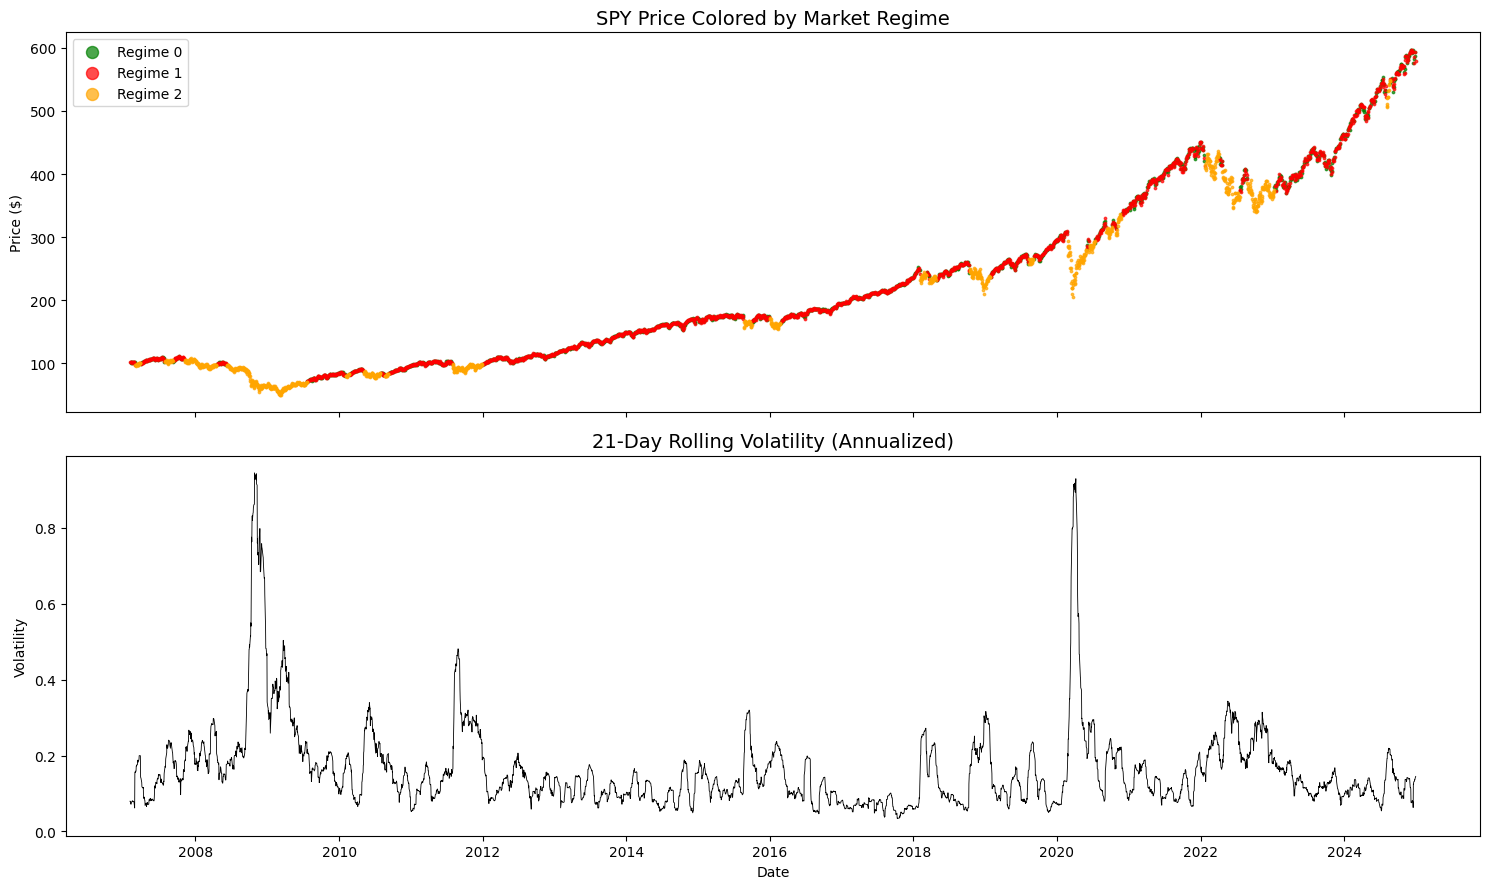

In [14]:
# plot price colored by regime
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

colors = {0: 'green', 1: 'red', 2: 'orange'}

for regime in range(3):
    mask = data['regime'] == regime
    axes[0].scatter(data.index[mask], data['Close'][mask],
                    c=colors[regime], s=3, label=f'Regime {regime}', alpha=0.7)

axes[0].set_title(f'{ticker} Price Colored by Market Regime', fontsize=14)
axes[0].set_ylabel('Price ($)')
axes[0].legend(markerscale=5)

# rolling volatility underneath
axes[1].plot(data.index, data['rolling_vol'] * np.sqrt(252), color='black', linewidth=0.6)
axes[1].set_title('21-Day Rolling Volatility (Annualized)', fontsize=14)
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Observations

The HMM picks up three fairly distinct regimes. One corresponds to calm, low-vol bull markets (most of the time), another captures high-volatility selloffs (2008, 2020, late 2022), and the third sits somewhere in between — transitional or sideways periods.

The model isn't perfect — there's some noise in the transitions — but it does a solid job at flagging the major regime shifts. You could use this as a filter for other strategies, e.g. only taking long positions in the bull regime.